# OTT Customer Churn Analysis — Exploratory Data Analysis

## Objective

The objective of this notebook is to explore customer, subscription, and support data to identify patterns and factors associated with customer churn.

The analysis will focus on:

- Customer demographics
- Subscription and plan characteristics
- Customer support interactions
- Churn-related patterns
- Key business insights

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load cleaned datasets

customer_df = pd.read_csv("../data/cleaned/customer_clean.csv")
subscription_df = pd.read_csv("../data/cleaned/subscription_clean.csv")
support_df = pd.read_csv("../data/cleaned/support_clean.csv")

print("Cleaned datasets loaded successfully.")

print("Customer:", customer_df.shape)
print("Subscription:", subscription_df.shape)
print("Support:", support_df.shape)

Cleaned datasets loaded successfully.
Customer: (600, 8)
Subscription: (600, 11)
Support: (648, 7)


In [3]:
# Create churn status

subscription_df["churn_status"] = np.where(
    subscription_df["cancellation_date"].notna(),
    "Churned",
    "Active"
)

subscription_df["churn_status"].value_counts()

churn_status
Churned    329
Active     271
Name: count, dtype: int64

In [4]:
# Calculate churn distribution

churn_distribution = (
    subscription_df["churn_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

churn_distribution

churn_status
Churned    54.83
Active     45.17
Name: proportion, dtype: float64

## Overall Churn Rate — Observation

Out of 600 customers:

- **329 customers (54.83%)** have churned.
- **271 customers (45.17%)** are currently active.

The overall churn rate is **54.83%**, meaning more than half of the customers in the dataset have churned.

This indicates a significant customer retention problem and establishes the baseline churn rate for the subsequent analysis.

**Business Perspective:**  
The next analysis will focus on identifying the customer, subscription, and support-related factors associated with this high churn rate.

In [5]:
plan_churn_count = pd.crosstab(
    subscription_df["plan_type"],
    subscription_df["churn_status"]
)

plan_churn_count

churn_status,Active,Churned
plan_type,,
Basic,26,118
Premium,93,130
Standard,152,81


In [6]:
plan_churn_rate = pd.crosstab(
    subscription_df["plan_type"],
    subscription_df["churn_status"],
    normalize="index"
).mul(100).round(2)

plan_churn_rate

churn_status,Active,Churned
plan_type,,
Basic,18.06,81.94
Premium,41.70,58.30
Standard,65.24,34.76


In [7]:
contract_churn_count = pd.crosstab(
    subscription_df["contract_type"],
    subscription_df["churn_status"]
)

contract_churn_rate = pd.crosstab(
    subscription_df["contract_type"],
    subscription_df["churn_status"],
    normalize="index"
).mul(100).round(2)

print("Churn Count:")
display(contract_churn_count)

print("\nChurn Rate (%):")
display(contract_churn_rate)

Churn Count:


churn_status,Active,Churned
contract_type,,
Annual,183,121
Monthly,88,208



Churn Rate (%):


churn_status,Active,Churned
contract_type,,
Annual,60.20,39.80
Monthly,29.73,70.27


## Churn by Contract Type — Observation

Contract type shows a substantial difference in customer churn.

- **Monthly contract:** 70.27% churn rate (208 of 296 customers)
- **Annual contract:** 39.80% churn rate (121 of 304 customers)

Customers on Monthly contracts have a substantially higher churn rate than customers on Annual contracts.

**Business Insight:**  
Monthly-contract customers appear to be a high-risk customer segment. The business should investigate whether shorter commitment, pricing, renewal behavior, or other subscription characteristics contribute to this higher churn.

This analysis shows an association between contract type and churn; it does not establish causation.

In [8]:
plan_contract_churn = pd.crosstab(
    [subscription_df["plan_type"],
     subscription_df["contract_type"]],
    subscription_df["churn_status"],
    normalize="index"
).mul(100).round(2)

plan_contract_churn

churn_status             Active  Churned
plan_type contract_type                 
Basic     Annual          50.00    50.00
          Monthly         17.14    82.86
Premium   Annual          57.76    42.24
          Monthly          0.00   100.00
Standard  Annual          63.31    36.69
          Monthly         68.09    31.91

In [10]:
plan_contract_count = pd.crosstab(
    [subscription_df["plan_type"],
     subscription_df["contract_type"]],
    subscription_df["churn_status"]
)

plan_contract_count

churn_status             Active  Churned
plan_type contract_type                 
Basic     Annual              2        2
          Monthly            24      116
Premium   Annual             93       68
          Monthly             0       62
Standard  Annual             88       51
          Monthly            64       30

## Churn by Plan and Contract Type — Observation

The combined analysis of plan type and contract type shows different churn patterns across customer segments.

- **Basic + Monthly:** 82.86% churn rate
- **Basic + Annual:** 50.00% churn rate
- **Premium + Monthly:** 100.00% churn rate
- **Premium + Annual:** 42.24% churn rate
- **Standard + Monthly:** 31.91% churn rate
- **Standard + Annual:** 36.69% churn rate

Basic customers on Monthly contracts show substantially higher churn than Basic customers on Annual contracts.

Premium Monthly customers show a 100% churn rate in this dataset. However, the segment size should be checked before treating this as a strong business conclusion.

Standard customers show relatively low churn in both contract types.

**Business Insight:**

Contract type appears to interact with plan type in the observed churn patterns. Monthly customers, particularly those on the Basic plan, represent an important high-risk segment that should receive further investigation.

The Premium Monthly 100% churn rate should be interpreted cautiously because the result may be influenced by a small segment size.

### Segment Size Consideration

The Premium + Monthly segment contains 62 customers, all of whom are recorded as churned. Therefore, the 100% churn rate represents a meaningful observed pattern within this dataset, although further investigation is required before concluding the underlying cause.

The Basic + Annual segment contains only 4 customers, so its 50% churn rate should be interpreted cautiously due to the very small sample size.

In [11]:
subscription_type_churn = pd.crosstab(
    subscription_df["subscription_type"],
    subscription_df["churn_status"]
)

subscription_type_churn_rate = pd.crosstab(
    subscription_df["subscription_type"],
    subscription_df["churn_status"],
    normalize="index"
).mul(100).round(2)

print("Churn Count:")
display(subscription_type_churn)

print("\nChurn Rate (%):")
display(subscription_type_churn_rate)

Churn Count:


churn_status,Active,Churned
subscription_type,,
Organic,105,99
Paid,74,84
Referral,92,145
Unknown,0,1



Churn Rate (%):


churn_status,Active,Churned
subscription_type,,
Organic,51.47,48.53
Paid,46.84,53.16
Referral,38.82,61.18
Unknown,0.00,100.00


## Churn by Subscription Type — Observation

Churn rates vary across customer acquisition types.

- **Referral:** 61.18% churn rate (145 of 237 customers)
- **Paid:** 53.16% churn rate (84 of 158 customers)
- **Organic:** 48.53% churn rate (99 of 204 customers)

Referral customers have the highest churn rate among the three meaningful acquisition categories, while Organic customers have the lowest.

**Business Insight:**  
Referral-acquired customers appear to have higher churn than Organic and Paid customers in this dataset. This suggests that the business should investigate whether referred customers have different expectations, onboarding experiences, or customer characteristics.

However, acquisition type alone does not establish the reason for churn. Further analysis with contract type, plan type, and support behavior is required.

The `Unknown` category contains only one customer and is therefore excluded from meaningful business interpretation.

In [12]:
customer_escalations = (
    support_df.groupby("customerid")["escalations"]
    .sum()
    .reset_index(name="total_escalations")
)

customer_escalations.head()

,customerid,total_escalations
0,CUST-0003,1
1,CUST-0005,2
2,CUST-0006,2
3,CUST-0007,2
4,CUST-0009,1


In [13]:
customer_escalations["escalation_group"] = np.select(
    [
        customer_escalations["total_escalations"] == 0,
        customer_escalations["total_escalations"] == 1,
        customer_escalations["total_escalations"] >= 2
    ],
    [
        "No Escalation",
        "1 Escalation",
        "2+ Escalations"
    ],
    default="Unknown"
)

customer_escalations["escalation_group"].value_counts()

escalation_group
No Escalation     135
1 Escalation      112
2+ Escalations     75
Name: count, dtype: int64

In [14]:
escalation_churn = subscription_df[
    ["customerid", "churn_status"]
].merge(
    customer_escalations[
        ["customerid", "total_escalations", "escalation_group"]
    ],
    on="customerid",
    how="left"
)

escalation_churn.head()

,customerid,churn_status,total_escalations,escalation_group
0,CUST-0001,Active,NaN,NaN
1,CUST-0002,Churned,NaN,NaN
2,CUST-0003,Active,1.0,1 Escalation
3,CUST-0004,Churned,NaN,NaN
4,CUST-0005,Churned,2.0,2+ Escalations


In [15]:
# Keep customers who have support records
escalation_churn_valid = escalation_churn.dropna(
    subset=["escalation_group"]
)

print("Customers with support records:",
      len(escalation_churn_valid))

print("\nEscalation group distribution:")
print(
    escalation_churn_valid["escalation_group"]
    .value_counts()
)

Customers with support records: 322

Escalation group distribution:
escalation_group
No Escalation     135
1 Escalation      112
2+ Escalations     75
Name: count, dtype: int64


In [16]:
# Churn rate by escalation group

escalation_churn_rate = pd.crosstab(
    escalation_churn_valid["escalation_group"],
    escalation_churn_valid["churn_status"],
    normalize="index"
).mul(100).round(2)

escalation_churn_rate

churn_status,Active,Churned
escalation_group,,
1 Escalation,45.54,54.46
2+ Escalations,44.00,56.00
No Escalation,42.96,57.04


## Churn by Support Escalation — Observation

Among the 322 customers with available support records, churn rates were relatively similar across escalation groups.

- **No Escalation:** 57.04% churn rate
- **1 Escalation:** 54.46% churn rate
- **2+ Escalations:** 56.00% churn rate

There is no clear increasing or decreasing trend in churn as the number of escalations increases.

**Business Insight:**

Support escalation count alone does not appear to be a strong differentiating factor for churn in this dataset. Customers with no escalation, one escalation, and multiple escalations all show relatively similar churn rates.

Therefore, escalation count should not be considered a primary churn driver based on this analysis alone.

**Data Limitation:**

This analysis covers only 322 customers with available support records. Customers without support records were excluded because the absence of a support record cannot automatically be interpreted as zero escalations.

In [17]:
customer_csat = (
    support_df.groupby("customerid")["csat_score"]
    .mean()
    .reset_index(name="avg_csat")
)

customer_csat.head()

,customerid,avg_csat
0,CUST-0003,4.0
1,CUST-0005,3.5
2,CUST-0006,3.5
3,CUST-0007,3.0
4,CUST-0009,3.0


In [18]:
csat_churn = subscription_df[
    ["customerid", "churn_status"]
].merge(
    customer_csat,
    on="customerid",
    how="inner"
)

print("Customers with CSAT data:", len(csat_churn))

csat_churn.head()

Customers with CSAT data: 322


,customerid,churn_status,avg_csat
0,CUST-0003,Active,4.0
1,CUST-0005,Churned,3.5
2,CUST-0006,Active,3.5
3,CUST-0007,Churned,3.0
4,CUST-0009,Churned,3.0


In [19]:
csat_churn["csat_group"] = pd.cut(
    csat_churn["avg_csat"],
    bins=[0, 2, 3, 4, 5],
    labels=["Low (1-2)", "Below Average (2-3)", "Good (3-4)", "Excellent (4-5)"],
    include_lowest=True
)

csat_churn["csat_group"].value_counts().sort_index()

csat_group
Low (1-2)               37
Below Average (2-3)     86
Good (3-4)             120
Excellent (4-5)         66
Name: count, dtype: int64

In [20]:
csat_churn_rate = pd.crosstab(
    csat_churn["csat_group"],
    csat_churn["churn_status"],
    normalize="index"
).mul(100).round(2)

csat_churn_rate

churn_status,Active,Churned
csat_group,,
Low (1-2),43.24,56.76
Below Average (2-3),40.70,59.30
Good (3-4),46.67,53.33
Excellent (4-5),45.45,54.55


## Churn by Customer Satisfaction (CSAT) — Observation

Among the 322 customers with available CSAT data, churn rates were relatively similar across all CSAT groups.

- **Low (1–2):** 56.76% churn rate
- **Below Average (2–3):** 59.30% churn rate
- **Good (3–4):** 53.33% churn rate
- **Excellent (4–5):** 54.55% churn rate

The Below Average CSAT group has the highest observed churn rate, while the Good CSAT group has the lowest.

However, the differences are relatively small, and there is no clear trend showing that lower CSAT consistently leads to higher churn.

**Business Insight:**

CSAT score alone does not appear to be a strong differentiating factor for churn in this dataset. Therefore, customer satisfaction should not be treated as a primary churn driver based on this analysis alone.

The analysis is limited to the 322 customers with available CSAT records.

In [21]:
monthly_charges_churn = (
    subscription_df
    .groupby("churn_status")["monthly_charges"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

monthly_charges_churn

,count,mean,median,min,max
churn_status,,,,,
Active,271,18.84,13.99,-10.0,999.00
Churned,329,13.53,13.49,0.0,23.49


## Monthly Charges by Churn Status — Observation

The monthly charge distribution shows a noticeable difference in the mean values between active and churned customers.

- **Active customers:** Mean = 18.84, Median = 13.99
- **Churned customers:** Mean = 13.53, Median = 13.49

Although active customers have a higher mean monthly charge, the median values are very similar.

The active group contains two previously identified anomalous values: `-10.00` and `999.00`. These extreme values substantially influence the mean and make the average less representative of the typical customer.

Therefore, the median provides a more reliable comparison in this case. Based on the median values, there is no substantial difference in typical monthly charges between active and churned customers.

**Business Insight:**

Monthly charges alone do not show a clear relationship with churn based on the current data. The identified anomalous values should also be considered when interpreting pricing-related metrics.

In [22]:
cltv_churn = (
    subscription_df
    .groupby("churn_status")["cltv"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

cltv_churn

,count,mean,median,min,max
churn_status,,,,,
Active,271,1151.92,935.0,60,2560
Churned,329,719.62,555.0,95,2235


## CLTV by Churn Status — Observation

Customer Lifetime Value (CLTV) differs substantially between active and churned customers.

- **Active customers:** Mean CLTV = 1,151.92; Median CLTV = 935
- **Churned customers:** Mean CLTV = 719.62; Median CLTV = 555

Both the mean and median CLTV are considerably higher among active customers.

**Business Insight:**

Customers who have churned tend to have lower lifetime value than customers who remain active. This suggests that lower-value customer segments may require different retention strategies and may represent an important segment for churn analysis.

However, CLTV alone does not establish that low CLTV causes churn. Other factors such as plan type, contract type, acquisition channel, and customer behavior should be considered together when identifying high-risk customers.

# EDA Summary

The exploratory analysis identified several notable differences in churn across plan type, contract type, acquisition type, and customer lifetime value.

## Visualization 1 — Overall Churn Distribution

This visualization shows the overall distribution of active and churned customers.

The dataset contains 329 churned customers (54.83%) and 271 active customers (45.17%).

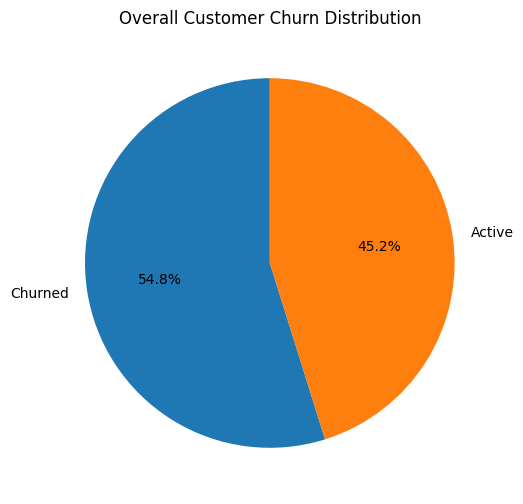

In [23]:
import matplotlib.pyplot as plt

churn_counts = subscription_df["churn_status"].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Overall Customer Churn Distribution")

plt.show()

### Observation

More than half of the customers in the dataset have churned, resulting in an overall churn rate of 54.83%.

This indicates a significant customer retention challenge and provides the business context for the subsequent churn analysis.

## Visualization 2 — Churn by Plan Type

This visualization compares the churn rate across Basic, Premium, and Standard subscription plans.

The Basic plan shows the highest observed churn rate at 81.94%, while the Standard plan has the lowest at 34.76%.

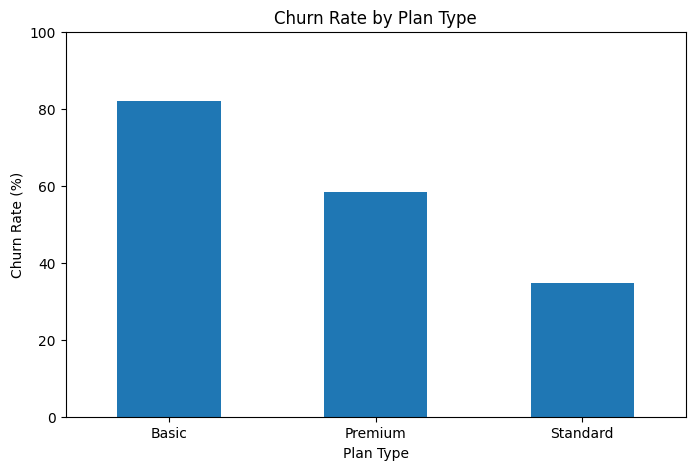

In [24]:
plan_churn_rate = pd.crosstab(
    subscription_df["plan_type"],
    subscription_df["churn_status"],
    normalize="index"
).mul(100).round(2)

plan_churn_rate["Churned"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Plan Type")
plt.xlabel("Plan Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.show()

### Observation

The Basic plan has the highest observed churn rate at **81.94%**, followed by Premium at **58.30%** and Standard at **34.76%**.

This indicates that Basic-plan customers represent a particularly high-risk segment and should be investigated further from a pricing, feature, content, and customer-expectation perspective.

## Visualization 3 — Churn Rate by Contract Type

This visualization compares churn rates between Monthly and Annual contract customers.

Monthly-contract customers have a substantially higher observed churn rate than Annual-contract customers.

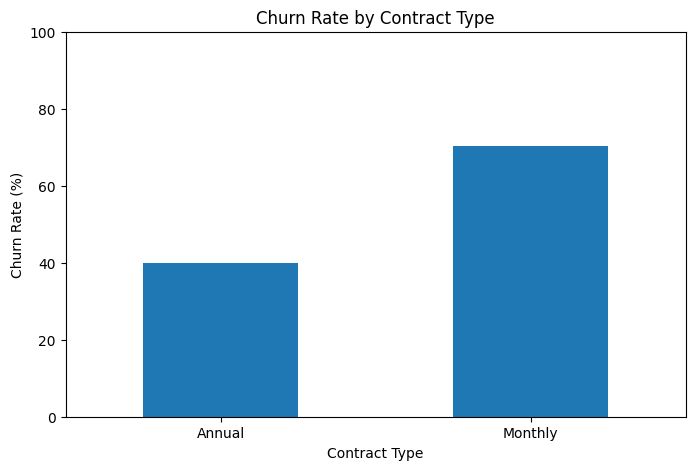

In [25]:
contract_churn_rate = pd.crosstab(
    subscription_df["contract_type"],
    subscription_df["churn_status"],
    normalize="index"
).mul(100).round(2)

contract_churn_rate["Churned"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.show()

### Observation

Monthly-contract customers have a **70.27%** observed churn rate, compared with **39.80%** among Annual-contract customers.

This represents a substantial difference in observed churn.

**Business Insight:**  
Monthly-contract customers should be considered a high-priority retention segment. The business should investigate whether lower contractual commitment, renewal behavior, pricing, or customer expectations contribute to the higher churn observed in this group.

## Visualization 4 — Churn Rate by Subscription Type

This visualization compares the observed churn rate across Organic, Paid, and Referral acquisition channels.

Referral customers show the highest churn rate among the three major acquisition types.

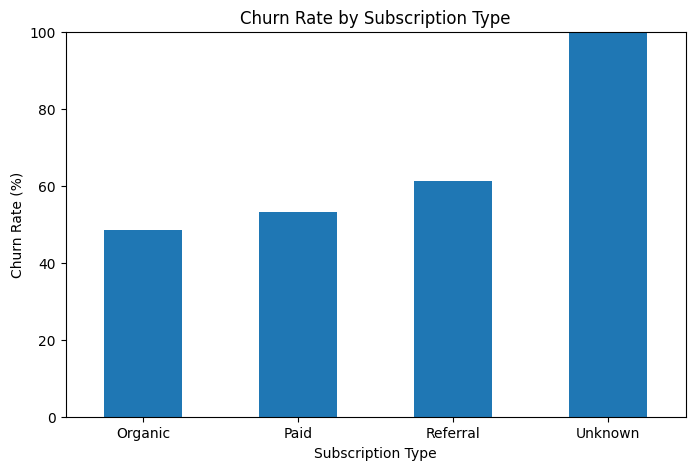

In [26]:
subscription_churn_rate = pd.crosstab(
    subscription_df["subscription_type"],
    subscription_df["churn_status"],
    normalize="index"
).mul(100).round(2)

subscription_churn_rate["Churned"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Subscription Type")
plt.xlabel("Subscription Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)

plt.show()

### Observation

Among the three identified subscription types, Referral customers have the highest observed churn rate at **61.18%**, followed by Paid customers at **53.16%** and Organic customers at **48.53%**.

The dataset also contains **1 customer with an Unknown subscription type**, and that customer was churned, resulting in a **100% observed churn rate** for the Unknown category.

However, this 100% rate is based on only **1 customer** and therefore should not be considered statistically meaningful or used as a major business finding.

**Business Insight:**

Referral-acquired customers represent a relatively higher-risk segment among the known subscription types. The business should investigate the onboarding experience, customer expectations, and long-term behavior of referred customers.

The Unknown category should be excluded from business interpretation because of its extremely small sample size.

## Visualization 5 — Churn Rate by Plan and Contract Type

This visualization compares churn rates across different combinations of plan type and contract type.

Combining these two subscription characteristics helps identify specific customer segments with particularly high observed churn.

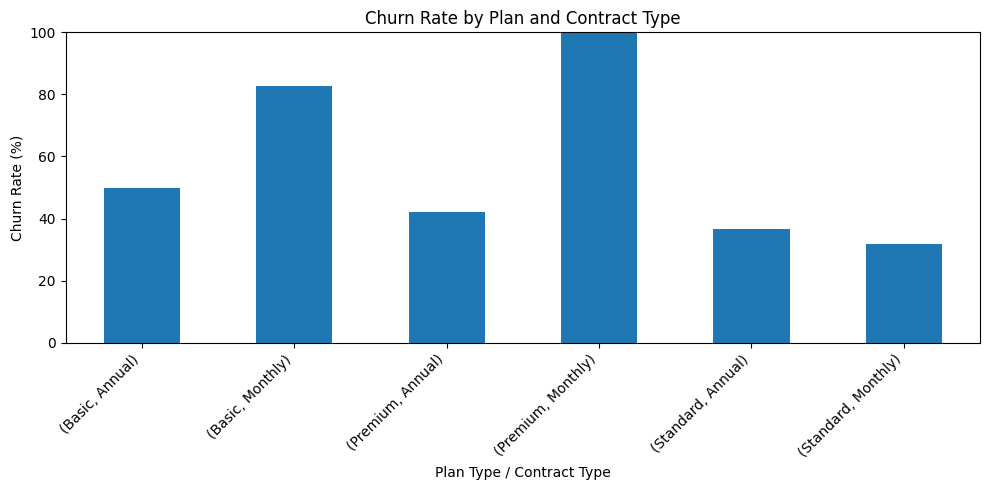

In [27]:
plan_contract_churn = pd.crosstab(
    [
        subscription_df["plan_type"],
        subscription_df["contract_type"]
    ],
    subscription_df["churn_status"],
    normalize="index"
).mul(100).round(2)

plan_contract_churn["Churned"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Churn Rate by Plan and Contract Type")
plt.xlabel("Plan Type / Contract Type")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, 100)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Observation

The combination of plan type and contract type reveals substantial differences in observed churn rates.

- **Basic + Monthly:** 82.86%
- **Premium + Monthly:** 100.00% (62 customers)
- **Basic + Annual:** 50.00% (4 customers)
- **Premium + Annual:** 42.24%
- **Standard + Annual:** 36.69%
- **Standard + Monthly:** 31.91%

The Premium + Monthly segment shows a 100% observed churn rate; however, this result is based on only 62 customers and should be interpreted with appropriate caution.

The Basic + Monthly segment is also a major high-risk segment because of its high churn rate and larger customer base.

**Business Insight:**

Retention strategies should be segment-specific rather than treating all plans and contracts equally. Basic + Monthly customers should receive particular attention because they combine a high observed churn rate with a meaningful customer volume.

## Visualization 6 — CLTV by Churn Status

This visualization compares the Customer Lifetime Value (CLTV) of active and churned customers.

The comparison helps evaluate whether customer value differs between customers who remain active and those who have churned.

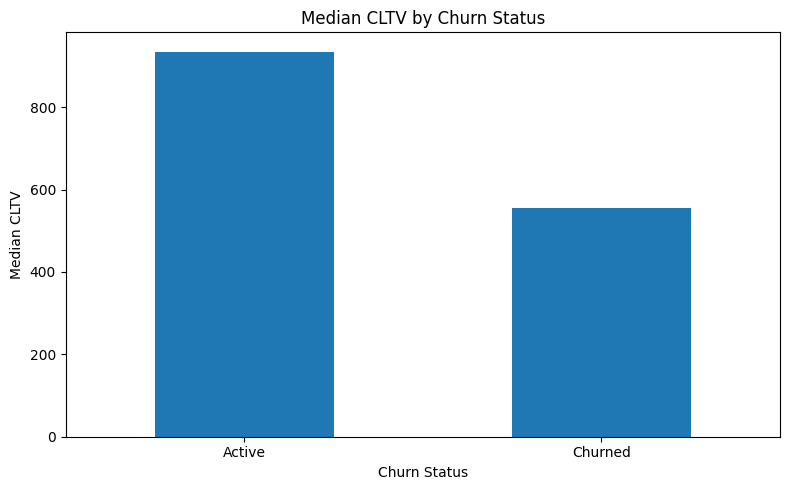

In [28]:
cltv_by_churn = (
    subscription_df
    .groupby("churn_status")["cltv"]
    .median()
)

cltv_by_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Median CLTV by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Median CLTV")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation

The median CLTV differs substantially between active and churned customers.

- **Active customers:** Median CLTV = **935**
- **Churned customers:** Median CLTV = **555**

Active customers have a substantially higher median CLTV than churned customers.

**Business Insight:**

CLTV can be used as an important customer-value metric when prioritizing retention efforts. Customers with high potential value and elevated churn risk may deserve greater retention attention.

However, the difference in CLTV should be interpreted as an observed association and should not be considered evidence that CLTV directly causes churn.

# Final EDA Summary

## Overall Churn

- Total customers: **600**
- Churned customers: **329**
- Active customers: **271**
- Overall churn rate: **54.83%**

## Major Churn Patterns

| Factor | Key Result |
|---|---|
| Plan Type | Basic has the highest churn rate: **81.94%** |
| Contract Type | Monthly: **70.27%** vs Annual: **39.80%** |
| Subscription Type | Referral: **61.18%** |
| Basic + Monthly | **82.86%** churn |
| Premium + Monthly | **100%** churn among 62 customers |
| CLTV | Active median: **935** vs Churned median: **555** |
| Escalations | No clear churn pattern |
| CSAT | No strong or consistent churn pattern |

## Key EDA Takeaways

The exploratory analysis shows that churn varies considerably across subscription-related characteristics.

The strongest observed differences are associated with:

1. **Plan Type**
2. **Contract Type**
3. **Plan × Contract Combination**
4. **Subscription Type**
5. **Customer Lifetime Value**

Support escalation count and CSAT showed relatively similar churn rates across their respective groups and therefore did not demonstrate strong patterns in this dataset.

> **Note:** These findings represent observed relationships within the available dataset and should not be interpreted as causal relationships.